# demetrapy: Copy, Run, Inspect

Adjust ten synthetic monthly emissions series with TRAMO/SEATS, then inspect component DataFrames, forward forecasts, and one fitted model.

Requires Python 3.11+, Java 9+, and a successful `demetrapy check`.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

from demetrapy import TramoSeatsConfig, adjust_dataframe, load_monthly_emissions

## 1. Copy and run

Load ten monthly series. The final expression displays the DataFrame shape.

In [9]:
data = load_monthly_emissions()
print(data.tail(3))
data.shape

                power  transport   industry  residential  commercial  \
date                                                                   
2024-10-01  70.690678  69.750071  42.023763    27.114483   28.905444   
2024-11-01  76.088743  67.167389  44.260454    32.667114   30.132894   
2024-12-01  81.679499  62.826435  47.467286    36.040935   30.449150   

            agriculture   aviation   shipping     waste  construction  
date                                                                   
2024-10-01    17.079067  21.992718  15.562252  8.660913     10.939479  
2024-11-01    16.396157  20.715832  14.694039  8.275877      9.811503  
2024-12-01    17.067592  19.877639  13.425566  7.771340      9.878077  


(120, 10)

## 2. Run the adjustment

One call processes every column. `prediction_length=12` requests twelve monthly forecast observations.

In [10]:
config = TramoSeatsConfig(
    spec="RSAfull",
    preprocessing={"automodel": {"enabled": True}},
    seats={"prediction_length": 12},
)

result = adjust_dataframe(data, config=config, detailed=True)

## 3. Inspect values and types

Split the two-level result into one date-indexed, ten-column DataFrame per component.

In [11]:
component_names = (
    "observed",
    "calendar_adjusted",
    "seasonally_adjusted",
    "trend",
    "seasonal",
    "irregular",
)

historical = {
    component: result.components.xs(
        component,
        axis="columns",
        level="component",
    )
    for component in component_names
}

print("Result type:", type(result))
print("Seasonally adjusted type:", type(historical["seasonally_adjusted"]))
print("Columns:", repr(list(historical["seasonally_adjusted"].columns)))
print("Shapes:", {name: frame.shape for name, frame in historical.items()})
historical["seasonally_adjusted"].tail()

Result type: <class 'demetrapy.dataframe.DataFrameAdjustmentResult'>
Seasonally adjusted type: <class 'pandas.DataFrame'>
Columns: ['power', 'transport', 'industry', 'residential', 'commercial', 'agriculture', 'aviation', 'shipping', 'waste', 'construction']
Shapes: {'observed': (120, 10), 'calendar_adjusted': (120, 10), 'seasonally_adjusted': (120, 10), 'trend': (120, 10), 'seasonal': (120, 10), 'irregular': (120, 10)}


series,power,transport,industry,residential,commercial,agriculture,aviation,shipping,waste,construction
date,,,,,,,,,,
2024-08-01,70.314293,70.366033,44.142367,28.349079,26.478150,20.066326,21.737088,14.336688,7.763676,11.772187
2024-09-01,70.500233,70.067976,44.014962,27.378743,25.890485,19.938154,22.204173,14.417052,7.921541,11.548679
2024-10-01,71.147496,70.403143,44.472003,27.215879,26.855618,20.163079,21.958662,14.671928,7.849239,11.781647
2024-11-01,69.505518,70.801147,44.236109,27.450874,26.465129,20.011429,22.252499,14.667507,7.807946,11.356978
2024-12-01,70.335443,70.129728,44.941433,26.618393,26.548760,20.227140,22.537041,14.428894,7.780572,11.745190


## 4. Inspect forward forecasts

The forecast index must begin after the final observed month.

In [12]:
forecast_result = result.to_forecast_frame()
forecast = {
    component: forecast_result.xs(
        component,
        axis="columns",
        level="component",
    )
    for component in component_names
}

assert forecast["seasonally_adjusted"].index[0] > data.index[-1]
print("Last observation:", data.index[-1].date())
print(
    "Forecast range:",
    forecast["seasonally_adjusted"].index[0].date(),
    "to",
    forecast["seasonally_adjusted"].index[-1].date(),
)
forecast["seasonally_adjusted"]

Last observation: 2024-12-01
Forecast range: 2025-01-01 to 2025-12-01


series,power,transport,industry,residential,commercial,agriculture,aviation,shipping,waste,construction
date,,,,,,,,,,
2025-01-01,70.068577,70.207923,44.349605,27.586536,26.324471,20.248508,22.408546,14.553351,7.818719,11.765081
2025-02-01,69.970192,70.593844,44.319174,27.525683,26.343002,20.262041,22.478606,14.582251,7.809504,11.804664
2025-03-01,69.871807,70.504442,44.288764,27.464830,26.361533,20.273882,22.548666,14.611152,7.800300,11.844246
2025-04-01,69.773422,70.563901,44.258374,27.403978,26.380064,20.285364,22.618726,14.640053,7.791106,11.883829
2025-05-01,69.675037,71.254756,44.228006,27.343125,26.398595,20.296773,22.688786,14.668953,7.781923,11.923411
2025-06-01,69.576652,70.859842,44.197658,27.282272,26.417126,20.308172,22.758846,14.697854,7.772752,11.962994
2025-07-01,69.478267,70.817918,44.167332,27.221420,26.435658,20.319573,22.828906,14.726755,7.763591,12.002577
2025-08-01,69.379882,70.745930,44.137026,27.160567,26.454189,20.330979,22.898967,14.755655,7.754440,12.042159
2025-09-01,69.281498,71.029446,44.106741,27.099714,26.472720,20.342392,22.969027,14.784556,7.745301,12.081742


## 5. Modify and rerun

Change `target` to any DataFrame column, then rerun the next two cells to inspect another fitted model and chart.

In [13]:
target = "power"  # Try "transport", "industry", or another column.
series_result = result.for_series(target)

print("Method:", series_result.method)
print("Specification:", series_result.specification)
print(
    "ARIMA:",
    series_result.arima_model.notation
    if series_result.arima_model is not None
    else "unavailable",
)
print("Diagnostics:", len(series_result.diagnostics))
print("Messages:", len(series_result.messages))

Method: tramoseats
Specification: RSAfull
ARIMA: ARIMA(0,0,0)(0,1,1)[12]
Diagnostics: 126
Messages: 1


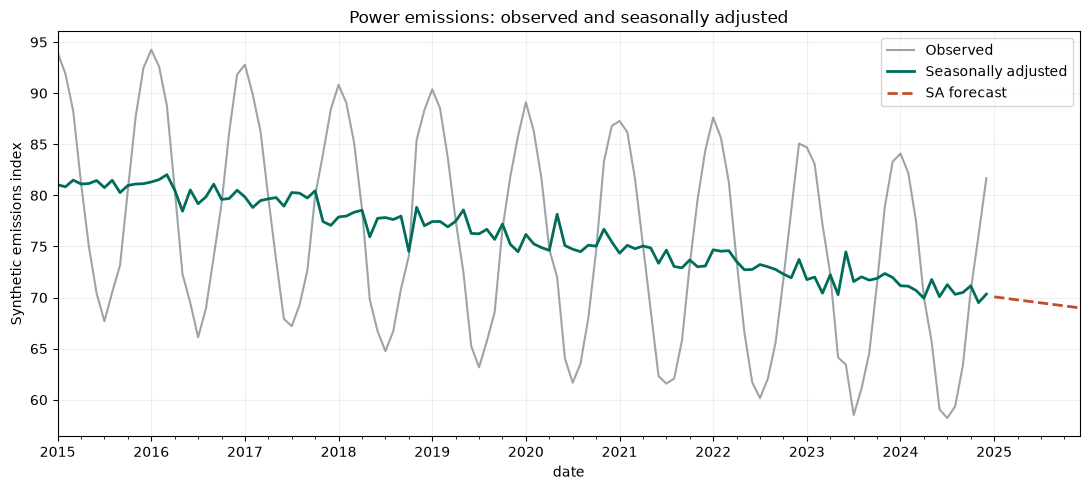

In [14]:
figure, axis = plt.subplots(figsize=(11, 5))
data[target].plot(ax=axis, label="Observed", color="#68747d", alpha=0.65)
historical["seasonally_adjusted"][target].plot(
    ax=axis,
    label="Seasonally adjusted",
    color="#006d5b",
    linewidth=2,
)
forecast["seasonally_adjusted"][target].plot(
    ax=axis,
    label="SA forecast",
    color="#c24d2c",
    linewidth=2,
    linestyle="--",
)
axis.set_title(f"{target.title()} emissions: observed and seasonally adjusted")
axis.set_ylabel("Synthetic emissions index")
axis.grid(alpha=0.2)
axis.legend()
figure.tight_layout()
plt.show()

## Where to go next

- [Full calendar-pool example](https://github.com/SermetPekin/demetrapy/blob/main/examples/13_full_config_calendar_pool.py): map different variables to each series while leaving extra pool columns unused.
- [Usage guide](https://github.com/SermetPekin/demetrapy/blob/main/docs/USAGE.md): sequences, CSV, configuration styles, auditing, plotting, and the dashboard.